<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/euler-and-solve-ivp-nworbehc/blob/main/EulerAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1

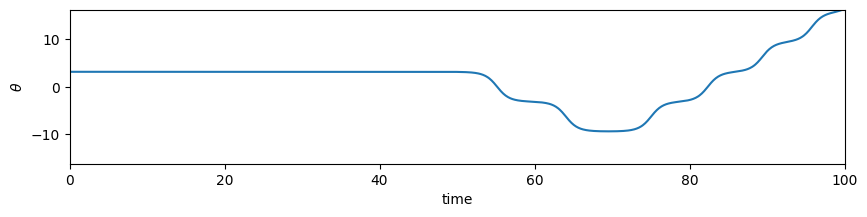

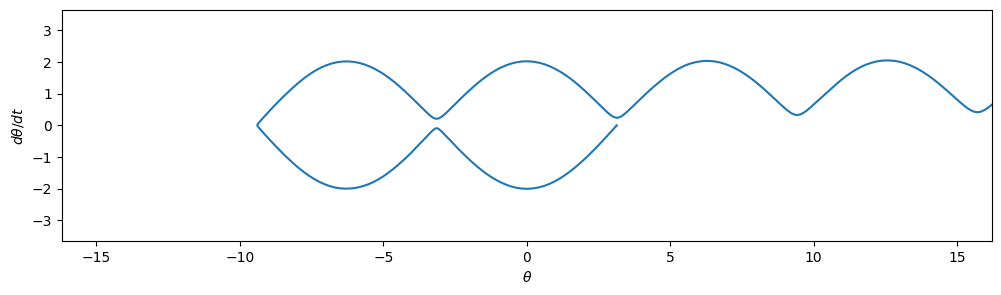

In [5]:
#FROM CLASS
import numpy as np  #imports the `numpy` package and gives it an alias/name `np`
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp   #imports the `solve_ivp` function from the `integrate` submodule of the `scipy` module

#define our differential equation
def rigid_pendulum_ode(t, y, omega_0=1):
 """
 Returns the time derivative of y=[theta, ang_vel] (the angle and angular velocity).
 """
 theta, ang_vel = y  #unpacks y=[theta, ang_vel]
 dtheta_dt = ang_vel  #define first derivative
 d2theta_dt2 = - omega_0 ** 2 * np.sin(theta)   #define second derivative
 dy_dt = [dtheta_dt, d2theta_dt2]   #define derivative of state variable
 return dy_dt

#Define the initial conditions, input parameters, and the time span

#initial conditions
theta_0 = np.pi   #initial angle
ang_vel_0 = 0   #initial angular velocity
y_0 = [theta_0, ang_vel_0]  #initial state

#input parameters
omega_0 = 1   #natural frequency

#time span
t_initial = 0   # initial time
t_final = 100   # final time
t_span = [t_initial, t_final]   # time span

#solve differential equation
solution = solve_ivp(rigid_pendulum_ode,
t_span,   #time span to solve over
y_0,  #initial conditions
 args=(omega_0,),   #passes `omega_0` to `rigid_pendulum_ode`
dense_output=True)  #returns an interpolated solution

#create list for plotting our solution
n_steps = 1000  #number of time steps
t_plot = np.linspace(t_initial, t_final, n_steps)   #list of times for plotting
theta_plot = solution.sol(t_plot)[0]  #evaluate the interpolant on a mesh for plotting
ang_vel_plot = solution.sol(t_plot)[1]  #evaluate the interpolant on a mesh for plotting

#plot the temporal evolution
plt.figure(figsize=(10,2))
plt.plot(t_plot, theta_plot)
plt.xlabel("time")
plt.ylabel("$\\theta$")
plt.xlim([0, 100])   #time
plt.ylim([- 5 * np.pi - 0.5, 5 * np.pi + 0.5])   #theta)
plt.show()

#plot the phase portrait
plt.figure(figsize=(12,3))
plt.plot(theta_plot, ang_vel_plot)
plt.xlabel("$\\theta$")
plt.ylabel("$d\\theta/dt$")
plt.xlim([- 5 * np.pi - 0.5, 5 * np.pi + 0.5])  #theta
plt.ylim([-  np.pi - 0.5,  np.pi + 0.5])  #angular velocity
plt.show()

**PROBLEM 1**
1. **Define parameters:** define natural frequency $\omega_0$, time $t$, number of steps $nsteps$, differential term $dt$. also define $\theta(t)$, $\omega(t)$ to be functions of time
2. **For normal euler:** Function should update $\theta$ and $\omega$ by $\theta_m = \theta_n + dt*\omega_n$ and $\omega_m = \omega_n - dt*\omega_0^2 *sin(\theta_n)$, where $m = n + 1$
3. **For semi implicit euler:** Function should update $\theta$ and $\omega$ by $\theta_m = \theta_n + dt*\omega_m$ and $\omega_m = \omega_n - dt*\omega_0^2 *sin(\theta_n)$, where $m = n + 1$
4. **Plot the results:** Plot evolution through time and the phase portrait
5. **Compare**: Compare how the two methods worked

In [24]:
#defining the things
omega_0 = 1
t_final = 100
N = 50000
dt = t_final / N
t = np.linspace(0, t_final, N+1)

def normal_euler(theta0, omega0, dt, N):
    theta = np.zeros(N+1)
    omega = np.zeros(N+1)
    theta[0], omega[0] = theta0, omega0
    for n in range(N):
        theta[n+1] = theta[n] + dt * omega[n]
        omega[n+1] = omega[n] - dt * (omega_0**2) * np.sin(theta[n])
    return theta, omega

def semi_implicit_euler(theta0, omega0, dt, N):
    theta = np.zeros(N+1)
    omega = np.zeros(N+1)
    theta[0], omega[0] = theta0, omega0
    for n in range(N):
        omega[n+1] = omega[n] - dt * (omega_0**2) * np.sin(theta[n])
        theta[n+1] = theta[n] + dt * omega[n+1]
    return theta, omega

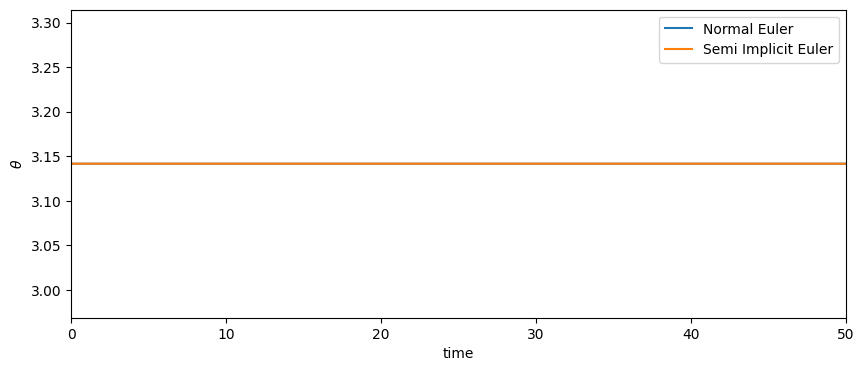

In [25]:
#for theta = pi and omega_0 = 0
theta0 = np.pi
omega0 = 0

theta_euler, omega_euler = normal_euler(theta0, omega0, dt, N)
theta_symp, omega_symp = semi_implicit_euler(theta0, omega0, dt, N)

plt.figure(figsize=(10,4))
plt.plot(t, theta_euler, label="Normal Euler")
plt.plot(t, theta_symp, label="Semi Implicit Euler")
plt.xlabel("time")
plt.ylabel(r"$\theta$")
plt.legend()
plt.xlim(0, 50)
plt.show()

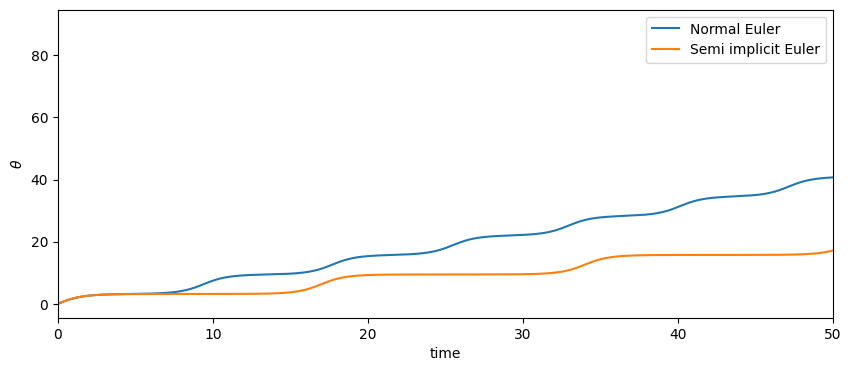

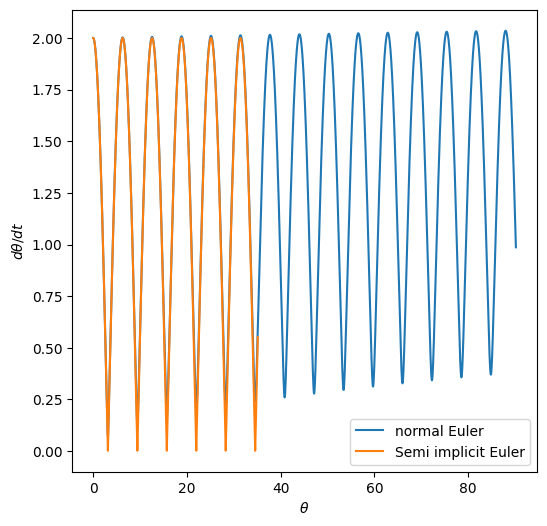

In [26]:
#for theta_0 = 0 and omega0 = 2
theta0 = 0
omega0 = 2

theta_euler, omega_euler = normal_euler(theta0, omega0, dt, N)
theta_symp, omega_symp = semi_implicit_euler(theta0, omega0, dt, N)

#evolution in time
plt.figure(figsize=(10,4))
plt.plot(t, theta_euler, label="Normal Euler")
plt.plot(t, theta_symp, label="Semi implicit Euler")
plt.xlabel("time")
plt.ylabel(r"$\theta$")
plt.legend()
plt.xlim(0, 50)
plt.show()

#Phase portrait
plt.figure(figsize=(6,6))
plt.plot(theta_euler, omega_euler, label="normal Euler")
plt.plot(theta_symp, omega_symp, label="Semi implicit Euler")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$d\theta/dt$")
plt.legend()
plt.show()

**Which was better?**
The semi-implicit euler method seemed to work better than the normal euler one, as the normal euler function did not show osciallations very well as time progressed, rather the seemed like the pendulum was swinging higher and higher, which shouldn't be possible in a closed system. The semi-implicit euler method also had this property, but it was not as pronounced as the normal euler method's was.
We did not go over "mesh density" in class, but from what I found on the internet it seems to be related to the dt value. I tried some low mesh densities and high mesh densities, and found that oscillations were more pronounced with the high densities that had more time steps. I settled on at dt value of 0.005 because anything higher didn't change the graphs much at all.

**Problem 2**
1. **Define parameters:** define natural frequency $\omega_0$, timespan $t_0$ to $t_f$, initial conditions $\theta_0, \omega_0$
2. **Define function:** Function the is called on later
3. **call solve_ivp:** get answers
4. **Plot the results:** Plot evolution through time for $\theta_0 = \pi, \omega_0 = 0$, and plot evolution through time and phase portrait for $\theta_0 = 0, \omega_0 = 2$.


In [27]:
#defining things
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def rigid_pendulum(t, y, omega_0=1.0):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = - (omega_0**2) * np.sin(theta)
    return [dtheta_dt, domega_dt]

# Parameters
omega_0 = 1.0
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

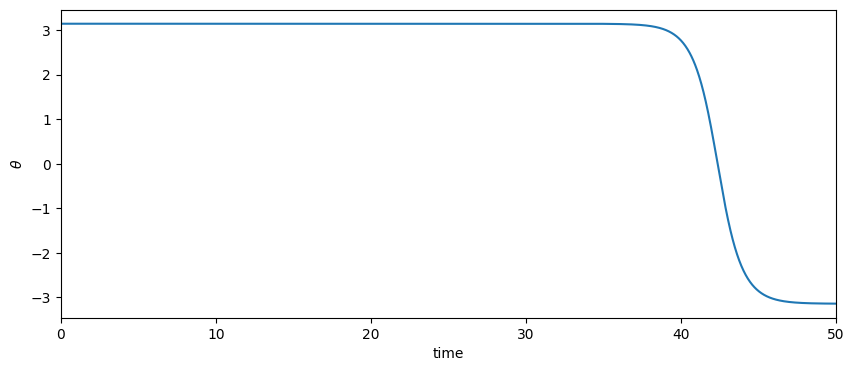

In [29]:
#for theta_0 = pi and omega_0 = 0
y0 = [np.pi, 0]

sol = solve_ivp(rigid_pendulum, t_span, y0, args=(omega_0,), rtol=1e-8, atol=1e-10, dense_output=True)

theta = sol.sol(t_eval)[0]

plt.figure(figsize=(10,4))
plt.plot(t_eval, theta)
plt.xlabel("time")
plt.ylabel(r"$\theta$")
plt.xlim([0, 50])
plt.show()


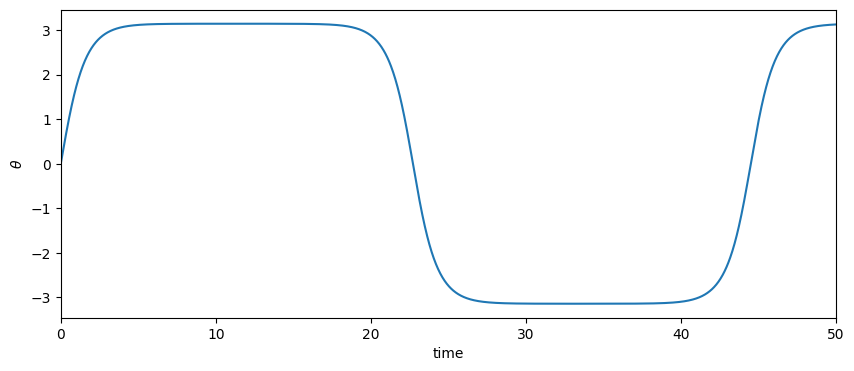

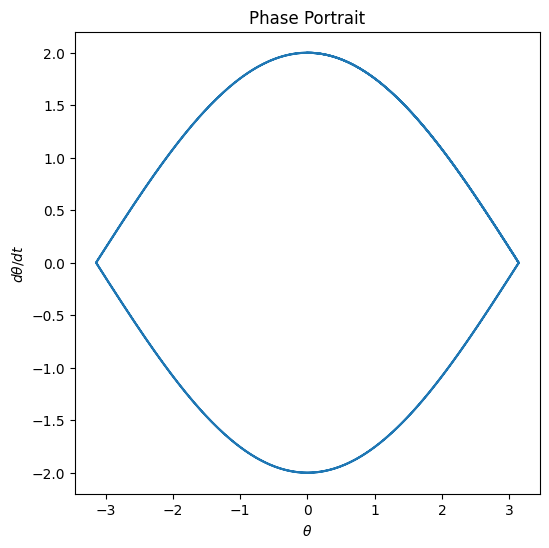

In [31]:
#for theta_0 = 0, omega_0 = 2
y0 = [0, 2]

sol = solve_ivp(rigid_pendulum, t_span, y0, args=(omega_0,),
                rtol=1e-8, atol=1e-10, dense_output=True)

theta = sol.sol(t_eval)[0]
omega = sol.sol(t_eval)[1]

# Temporal evolution
plt.figure(figsize=(10,4))
plt.plot(t_eval, theta)
plt.xlabel("time")
plt.ylabel(r"$\theta$")
plt.xlim([0, 50])
plt.show()

# Phase portrait
plt.figure(figsize=(6,6))
plt.plot(theta, omega)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$d\theta/dt$")
plt.title("Phase Portrait")
plt.show()

I kept it simple and used the default solver that was available using this function. I did however change the tolerances rtol and atol to be much smaller in order to keep the graph from going off the rails. The result was something that looked like periodic osciallatory motion but with a longer time spent at the extrema than a sin/cos type oscillation. This is consistent with what we talked about in class, so I believe that this is a reasonable solution to the rigid pendulum equation.

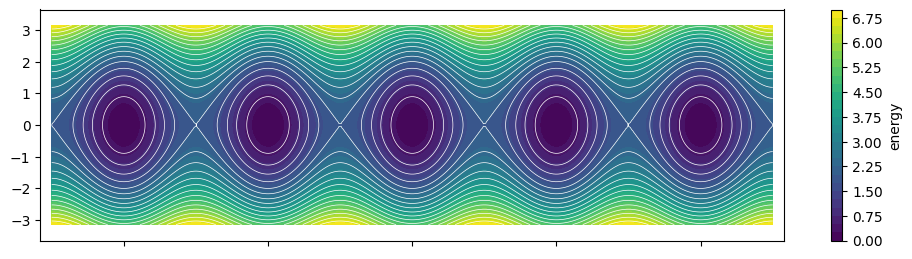

In [39]:
#debugged code, annotations where i debugged
import numpy as np
import matplotlib.pyplot as plt   #changed from pi to py

def rigid_pendulum_energy(theta, ang_vel, omega_0=1, moment_of_inertia=1):    #added colon
  energy = 0.5 * moment_of_inertia * ang_vel ** 2 + moment_of_inertia * omega_0 ** 2 * (1-np.cos(theta))  #spelling error
  return energy   #needed indent

theta_list = np.linspace(-5 * np.pi, 5 * np.pi, 300)
ang_vel_list = np.linspace(- np.pi,  np.pi, 100)

theta_mesh, ang_vel_mesh = np.meshgrid(theta_list, ang_vel_list)
energy_mesh = rigid_pendulum_energy(theta_mesh, ang_vel_mesh)

low_levels = np.linspace(0, 2, 5, endpoint=False)   #changed linespace to linspace
high_levels = np.linspace(2, energy_mesh.max(), 15)
levels = np.concatenate((low_levels, high_levels))

x_lim = [-5 * np.pi - 0.5, 5 * np.pi + 0.5]
y_lim = [- np.pi - 0.5, np.pi + 0.5]

x_ticks = np.pi * np.array([-4, -2, 0, 2, 4])  #used array to allow for multiplication
x_tick_labels = ['', '', '', '', '']

plt.figure(figsize=(12, 3))   #changed weird brackets to parenthesis

contours = plt.contourf(theta_mesh, ang_vel_mesh, energy_mesh, levels=30, cmap='viridis')

plt.contour(theta_mesh, ang_vel_mesh, energy_mesh, levels=levels, colors='white', linewidths=0.5)
plt.plot(theta_plot[0], ang_vel_plot[1], label='rigid pendulum', color='red', linewidth=0.5)
plt.colorbar(contours, label='energy')  #removed .

plt.xlabel('')
plt.ylabel('')

plt.xticks(x_ticks, x_tick_labels)
plt.yticks(range(-3,4,1))

plt.xlim(x_lim)
plt.ylim(y_lim)
plt.show()